# Online CAPTCHA inference with a MAP-centered proposal

This notebook fits `AutoMAPProposal` to an image from `data/examples`,
draws exact-discrete proposal particles, and corrects them against the
original generative model with self-normalized importance weights.

$$
\widetilde z^*=\operatorname*{argmax}_{\widetilde z}
\log\gamma_{\theta,\eta}(\widetilde z;x),\qquad
\widetilde w_s=
\frac{\gamma_\theta(z^{(s)};x)/q_\phi(z^{(s)}\mid x)}
{\sum_r\gamma_\theta(z^{(r)};x)/q_\phi(z^{(r)}\mid x)}.
$$

The reconstruction is $\sum_s\widetilde w_s\mu_\theta(z^{(s)})$.
The final cells report optimizer convergence, ESS, and weight collapse.


In [1]:
from pathlib import Path

import hydra
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import rootutils
from numpyro.optim import Adam
from PIL import Image

PROJECT_ROOT = rootutils.setup_root(
    Path.cwd(), indicator=".project-root", pythonpath=True
)

from src.inference.map_proposal_online import MAPProposalCaptchaInference


In [2]:
EXAMPLE_INDEX = 0
MAP_MAX_STEPS = 20
NUM_DISPERSION_PARTICLES = 8
NUM_IMPORTANCE_SAMPLES = 64
PROPOSAL_MAX_STEPS = 20
SEED = 0


def load_image(path, shape=(80, 80)):
    height, width = shape
    image = Image.open(path).convert("RGB").resize((width, height))
    array = np.asarray(image, dtype=np.float32) / 255.0
    return jnp.asarray(array)[None]


## Inspect the available observations

Change `EXAMPLE_INDEX` above to fit a different image. The inference cells
operate on whichever path is selected from this gallery.


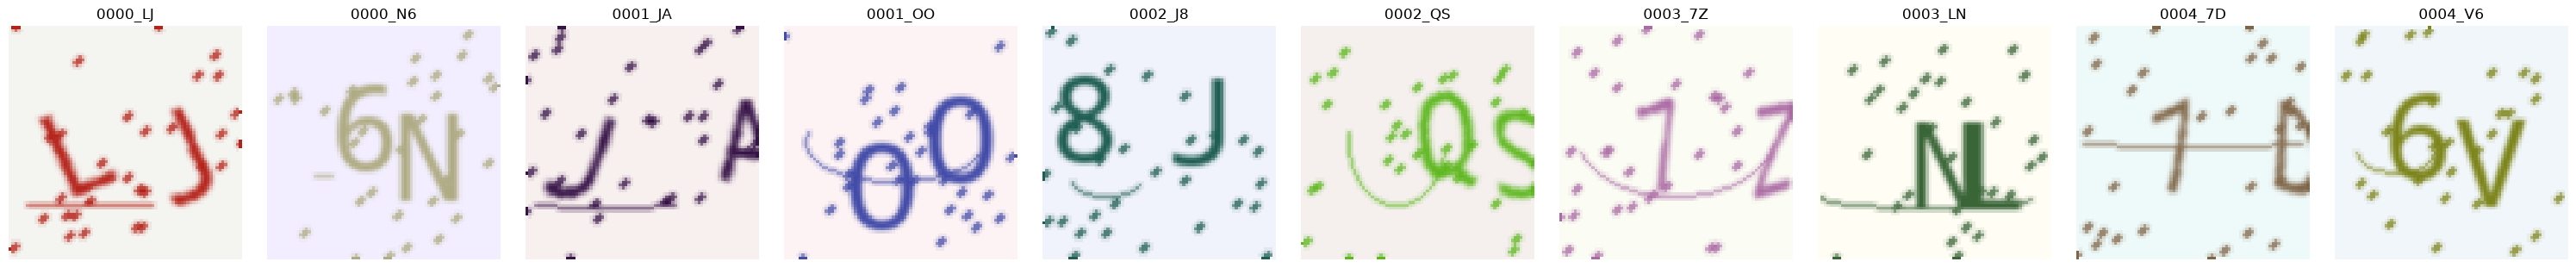

In [3]:
example_paths = sorted((PROJECT_ROOT / "data/examples").glob("*.png"))
if not example_paths:
    raise FileNotFoundError(PROJECT_ROOT / "data/examples")

figure, axes = plt.subplots(
    1, len(example_paths), figsize=(3 * len(example_paths), 3),
    constrained_layout=True, squeeze=False,
)
for axis, path in zip(axes[0], example_paths):
    axis.imshow(np.asarray(load_image(path)[0]))
    axis.set_title(path.stem)
    axis.set_axis_off()
selected_path = example_paths[EXAMPLE_INDEX]


## Fit and reuse the proposal

The first Adam fit locates a mode of the DSGD-relaxed target. The second
uses fresh Monte Carlo particles at each Adam step to fit the proposal
dispersions. After `fit` returns, drawing exact importance particles does
not optimize or otherwise modify the reusable fitted proposal.
Every one of the $H\times W\times K$ Poisson count coordinates remains
in the optimization and in the fitted proposal.
The full canonical texture and affine-free image warp remain latent. The
guide uses its ordinary support-aware initialization; there is no
observation-derived candidate set or handcrafted warm-start.


In [ ]:
config_directory = str(PROJECT_ROOT / "configs")
with hydra.initialize_config_dir(
    config_dir=config_directory, version_base="1.3"
):
    model_config = hydra.compose(config_name="model/poisson_convsc")
model_config.model.placements.shape_dict.path = str(
    PROJECT_ROOT / "data/captcha_sandbox/dictionary"
)
model = hydra.utils.instantiate(model_config.model)
images = load_image(
    selected_path,
    (model.keywords["placements"].height,
     model.keywords["placements"].width),
)
inference = MAPProposalCaptchaInference(
    model,
    dsgd_kwargs={"max_count": 16, "width": 32},
    map_max_steps=MAP_MAX_STEPS,
    map_optimizer=Adam(step_size=0.01),
    num_dispersion_particles=NUM_DISPERSION_PARTICLES,
    num_importance_samples=NUM_IMPORTANCE_SAMPLES,
    proposal_max_steps=PROPOSAL_MAX_STEPS,
    proposal_optimizer=Adam(step_size=0.01),
)
result = inference(jax.random.key(SEED), images)


In [ ]:
normalized_weights = np.asarray(result.normalized_weights)
top_particle = int(np.argmax(normalized_weights))
weighted_counts = np.asarray(result.weighted_counts)[0]
weighted_occupancy = weighted_counts.sum(axis=-1)
weighted_reconstruction = np.asarray(result.weighted_reconstruction)[0]

figure, axes = plt.subplots(1, 4, figsize=(17, 4),
                            constrained_layout=True)
axes[0].imshow(np.asarray(images[0]))
axes[0].set_title(f"Observation: {selected_path.stem}")
axes[0].set_axis_off()
axes[1].imshow(np.clip(weighted_reconstruction, 0.0, 1.0))
axes[1].set_title("Importance-weighted render")
axes[1].set_axis_off()
axes[2].imshow(np.clip(
    np.asarray(result.reconstructions[top_particle, 0]), 0.0, 1.0
))
axes[2].set_title("Highest-weight particle")
axes[2].set_axis_off()
occupancy_image = axes[3].imshow(weighted_occupancy, cmap="magma")
axes[3].set_title("Importance-weighted occupancy")
axes[3].set_axis_off()
figure.colorbar(occupancy_image, ax=axes[3], shrink=0.8)


In [ ]:
ordered_weights = np.sort(normalized_weights)[::-1]
figure, axis = plt.subplots(figsize=(6, 3), constrained_layout=True)
axis.semilogy(np.arange(1, len(ordered_weights) + 1),
              ordered_weights, marker=".")
axis.set_xlabel("Particle rank")
axis.set_ylabel("Normalized importance weight")
axis.set_title("Importance-weight concentration")
axis.grid(alpha=0.25)
print(f"MAP: {int(result.map_num_steps)} steps, "
      f"converged={bool(result.map_converged)}")
print(f"Dispersion: {int(result.dispersion_num_steps)} steps, "
      f"converged={bool(result.dispersion_converged)}")
print(f"ESS: {float(result.effective_sample_size):.2f} / "
      f"{NUM_IMPORTANCE_SAMPLES}")
print(f"Largest weight: {float(ordered_weights[0]):.4f}")
print(f"Expected total glyph count: {weighted_counts.sum():.3f}")
print(f"Largest site/class expectation: {weighted_counts.max():.3f}")
assert np.isfinite(weighted_reconstruction).all()
assert np.isclose(normalized_weights.sum(), 1.0)


## Interpretation

An ESS near one means that a single particle dominates: the computation
worked, but $q_\phi$ did not cover the relevant posterior well enough for
the chosen particle count. Non-convergence has the same status. Inspect
`result.map_losses` and `result.dispersion_losses` to distinguish a fit
that is still improving from one that has stalled. All spatial locations
and glyph identities can receive posterior mass; there is no candidate
selection approximation in this path.
